# Group 2 — Problem Analysis Workshop A

**Course:** PROG8431 — Data Analysis, Mathematics, Algorithms and Modeling  
**Project:** Police-Reported Cybercrime in Canada (Real Data from Statistics Canada)  
**Dataset:** Statistics Canada, Table 35-10-0002-01 (`35100002.csv`)  

| Team member | Student ID |
|---|---:|
| Senay Teweldebrhan | 9120588 |
| Juan Camilo Chirivi | 9115141 |
| Zeynep Ozdemir | 9045142 |



## 1. Overview of the data

The data to be analyzed in this notebook is about cyber crimes reported by police in Canada, taken from official government paper, so it contains real information about cyber crime incidents reported from 2014 to 2025. Includes country data such as provinces, territories and Metropolitan Census Areas (RCM).
The report can be interpreted in two ways: the number of cybercrime incidents and the incident rate per 100,000 inhabitants. 

## 2. Setup and configuration




In [20]:
# Standard Python tools for local files.
from pathlib import Path
import csv

# Data analysis, statistics, and chart libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# Make notebook tables easy to read.
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 65)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

# Statistical configuration.
ALPHA = 0.05
ANALYSIS_YEAR = 2025
TABLE_ID = "35100002"

print(f"Python notebook ready. Analysis year: {ANALYSIS_YEAR}, alpha: {ALPHA}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


Python notebook ready. Analysis year: 2025, alpha: 0.05
pandas 3.0.6 | numpy 2.5.3


## 3. Load the local real data

`35100002_MetaData.csv` is **documentation**, not a second dataset to join to the observations.


In [21]:
# ---------------------------------------------------------
# Find the Statistics Canada CSV locally
# ---------------------------------------------------------

current = Path.cwd()

# Local paths supported by this notebook:
# 1. project/data/35100002.csv
# 2. ../data/35100002.csv when the notebook runs from /notebooks
# 3. 35100002.csv in the current folder (useful for testing)
possible_paths = [
    current / "data" / "35100002.csv",
    current.parent / "data" / "35100002.csv",
    current / "35100002.csv",
]

csv_path = next((path for path in possible_paths if path.is_file()), None)

if csv_path is None:
    raise FileNotFoundError(
        "35100002.csv was not found. "
        "Place it inside the project's data folder."
    )

print(f"Using local file: {csv_path.resolve()}")

# Load the official Statistics Canada CSV.
raw_df = pd.read_csv(csv_path, low_memory=False)

# Confirm that the columns needed in later sections are available.
required_columns = {"REF_DATE", "GEO", "Statistics", "VALUE", "STATUS"}
assert required_columns.issubset(raw_df.columns), (
    "The CSV does not have the expected Statistics Canada columns."
)

print("Original dataset shape:", raw_df.shape)
print("Available years:", raw_df["REF_DATE"].min(), "to", raw_df["REF_DATE"].max())

display(raw_df.head(6))


Using local file: D:\Conestoga\Data A\Workshop A\Problem-Analysis-Workshop-A\data\35100002.csv
Original dataset shape: (1356, 15)
Available years: 2014 to 2025


,REF_DATE,GEO,DGUID,Statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2014,Total police-reported cybercrime,NaN,Number of cybercrime incidents,Number,223,units,0,v116321076,1.100,"15,184.000",NaN,NaN,NaN,0
1,2014,Total police-reported cybercrime,NaN,"Rate per 100,000 population","Rate per 100,000 population",265,units,0,v116321077,1.200,47.700,NaN,NaN,NaN,1
2,2014,Total Non-Census metropolitan area,NaN,Number of cybercrime incidents,Number,223,units,0,v116321078,2.100,"5,075.000",NaN,NaN,NaN,0
3,2014,Total Non-Census metropolitan area,NaN,"Rate per 100,000 population","Rate per 100,000 population",265,units,0,v116321079,2.200,58.100,NaN,NaN,NaN,1
4,2014,Total Census metropolitan area,NaN,Number of cybercrime incidents,Number,223,units,0,v116321080,3.100,"10,109.000",NaN,NaN,NaN,0
5,2014,Total Census metropolitan area,NaN,"Rate per 100,000 population","Rate per 100,000 population",265,units,0,v116321081,3.200,43.700,NaN,NaN,NaN,1


## 4. Inspect and clean the data

**Raw dataset:** Some rows represent Canada as a whole; others represent provinces or metropolitan areas. Also, `Statistics` contains **two different measurements** (number of incidents and rate per 100,000 people). We must not mix them in one distribution.

**Cleaning decisions:**
1. Convert `REF_DATE` and `VALUE` into numerical types.
2. Keep only the **rate per 100,000 population** for **2025**.
3. Keep valid full **CMA** geographic entries; do not mix in totals.
4. Exclude missing `VALUE` records rather than pretending they are zero.
5. Assign each CMA to **Ontario** or **other provinces** for comparison.

> `STATUS == ".."` means **data not available**, not zero. This is why missing numeric values must be handled carefully.

In [22]:
# Work on a copy so the original uploaded data remains unchanged.
df = raw_df.copy()
df["REF_DATE"] = pd.to_numeric(df["REF_DATE"], errors="coerce")
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")

print("Missing VALUE values in raw data:", df["VALUE"].isna().sum())
print("Exact duplicate rows in raw data:", df.duplicated().sum())
print("Available measurements:")
display(df["Statistics"].value_counts().to_frame("Rows"))

# Filter a single year and measurement; each selected row is one CMA.
rate_rows = df.loc[
    df["REF_DATE"].eq(ANALYSIS_YEAR)
    & df["Statistics"].eq("Rate per 100,000 population")
].copy()

# CMA names have a five-digit classification code, for example [35541].
is_full_cma = rate_rows["GEO"].str.contains(r"\[\d{5}\]", regex=True, na=False)
is_partial_cma = rate_rows["GEO"].str.contains(" part ", case=False, na=False)

cma_df = rate_rows.loc[is_full_cma & ~is_partial_cma].dropna(subset=["VALUE"]).copy()
cma_df = cma_df.rename(columns={"VALUE": "Rate_per_100k"})
cma_df["Region_Group"] = np.where(
    cma_df["GEO"].str.contains(r", Ontario \[", regex=True, na=False),
    "Ontario CMAs",
    "Other Canadian CMAs",
)
cma_df = cma_df[["REF_DATE", "GEO", "Region_Group", "Rate_per_100k"]]

assert len(cma_df) > 10, "Too few CMA observations for the requested analysis."
assert cma_df["Rate_per_100k"].ge(0).all(), "Cybercrime rates must not be negative."
assert not cma_df["GEO"].duplicated().any(), "A CMA is present more than once."

print(f"Selected {len(cma_df)} CMA records for {ANALYSIS_YEAR}.")
print("Analysis groups:")
display(cma_df.groupby("Region_Group")["Rate_per_100k"].agg(["count", "mean", "median", "std"]).round(2))
display(cma_df.head(8))

Missing VALUE values in raw data: 94
Exact duplicate rows in raw data: 0
Available measurements:


,Rows
Statistics,
Number of cybercrime incidents,678
"Rate per 100,000 population",678


Selected 39 CMA records for 2025.
Analysis groups:


,count,mean,median,std
Region_Group,,,,
Ontario CMAs,14,303.260,260.350,159.790
Other Canadian CMAs,25,303.790,270.700,193.400


,REF_DATE,GEO,Region_Group,Rate_per_100k
1249,2025,"St. John's, Newfoundland and Labrador [10001]",Other Canadian CMAs,114.700
1255,2025,"Halifax, Nova Scotia [12205]",Other Canadian CMAs,301.900
1259,2025,"Moncton, New Brunswick [13305]",Other Canadian CMAs,407.000
1261,2025,"Saint John, New Brunswick [13310]",Other Canadian CMAs,189.700
1263,2025,"Fredericton, New Brunswick [13320]",Other Canadian CMAs,207.200
1267,2025,"Saguenay, Quebec [24408]",Other Canadian CMAs,69.000
1269,2025,"Québec, Quebec [24421]",Other Canadian CMAs,118.100
1271,2025,"Sherbrooke, Quebec [24433]",Other Canadian CMAs,175.600


## 5. Histograms — understand the distribution

A **histogram** shows how frequently different ranges of cybercrime rates occur. We show (1) all included CMAs and (2) the two regional groups. Rates are **incidents per 100,000 population**, not percentages.

**Interpretation question:** Are most metropolitan areas near the average, or are a few rates much higher than the others? A right-skewed distribution has a longer tail toward large values.

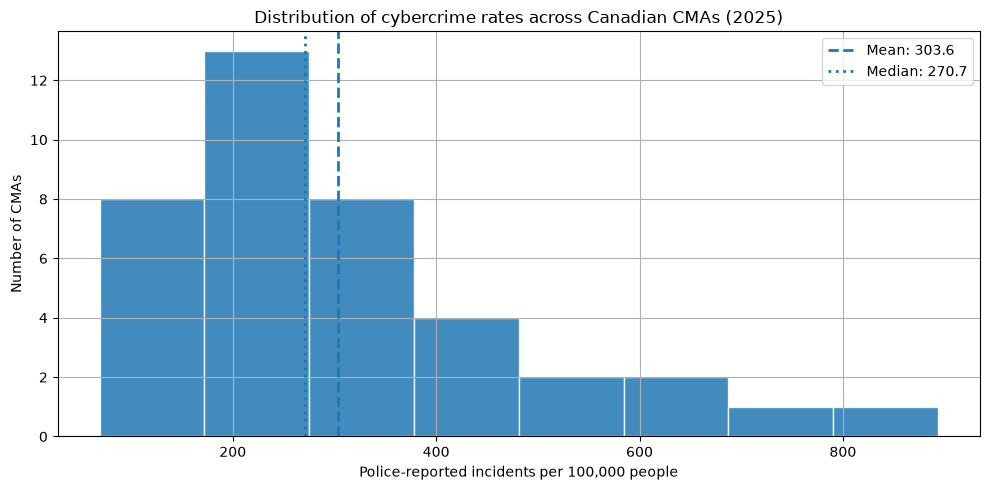

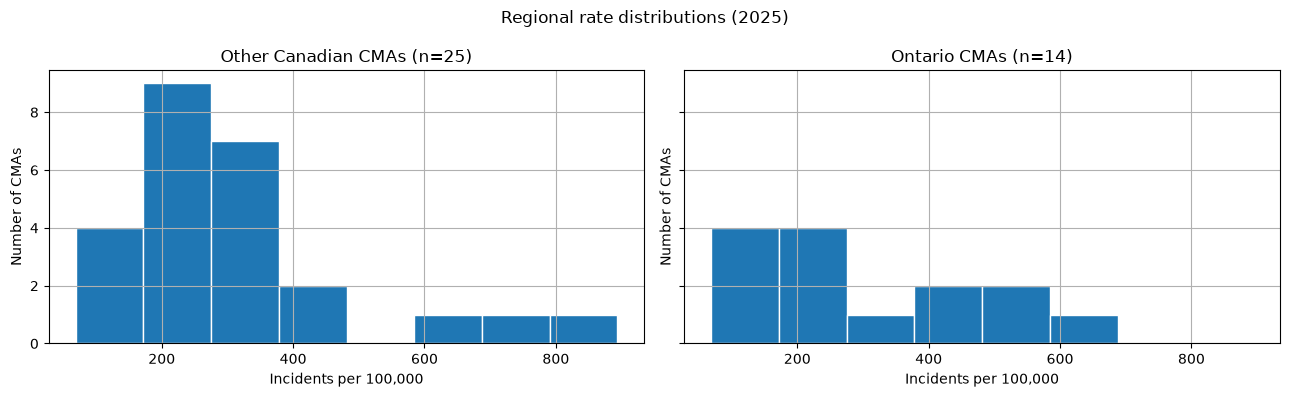

Overall mean: 303.6
Overall median: 270.7
Overall sample standard deviation: 179.89
Overall skewness: 1.4


In [23]:
# Set common histogram bins to make comparisons fair.
rates = cma_df["Rate_per_100k"]
all_bins = np.histogram_bin_edges(rates, bins="auto")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rates, bins=all_bins, edgecolor="white", alpha=0.85)
ax.axvline(rates.mean(), linestyle="--", linewidth=2, label=f"Mean: {rates.mean():.1f}")
ax.axvline(rates.median(), linestyle=":", linewidth=2, label=f"Median: {rates.median():.1f}")
ax.set(title=f"Distribution of cybercrime rates across Canadian CMAs ({ANALYSIS_YEAR})",
       xlabel="Police-reported incidents per 100,000 people", ylabel="Number of CMAs")
ax.legend()
plt.tight_layout()
plt.show()

# Same bins for both groups so their ranges can be visually compared.
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
for ax, (group_name, group_df) in zip(axes, cma_df.groupby("Region_Group", sort=False)):
    ax.hist(group_df["Rate_per_100k"], bins=all_bins, edgecolor="white")
    ax.set(title=f"{group_name} (n={len(group_df)})",
           xlabel="Incidents per 100,000", ylabel="Number of CMAs")
plt.suptitle(f"Regional rate distributions ({ANALYSIS_YEAR})")
plt.tight_layout()
plt.show()

print("Overall mean:", round(rates.mean(), 2))
print("Overall median:", round(rates.median(), 2))
print("Overall sample standard deviation:", round(rates.std(ddof=1), 2))
print("Overall skewness:", round(stats.skew(rates, bias=False), 2))

## 6. Z-score — identify unusually high or low rates

A **Z-score** tells us how far one metropolitan area's rate is from the average in units of standard deviations.

$$z_i = \frac{x_i - \bar{x}}{s}$$

Here, `x` is a CMA rate, `x̄` is the mean of all selected CMA rates, and `s` is their **sample** standard deviation. We flag `|z| > 2` as *unusual compared with this dataset*. **Important:** a high Z-score does not prove a city is experiencing more actual attacks, nor does it prove a probability of occurrence when the distribution is not normal.

In [24]:
# Standardize the same numeric variable across all 2025 CMAs.
mean_rate = rates.mean()
std_rate = rates.std(ddof=1)  # ddof=1 means sample standard deviation.
assert std_rate > 0, "Z-scores cannot be calculated if all values are equal."

cma_df["Z_score"] = (cma_df["Rate_per_100k"] - mean_rate) / std_rate
cma_df["Absolute_Z"] = cma_df["Z_score"].abs()

print(f"Mean = {mean_rate:.2f} | Sample SD = {std_rate:.2f}")
print("CMAs with |Z-score| > 2:", (cma_df["Absolute_Z"] > 2).sum())
print("Five CMAs farthest from the average:")
display(cma_df.nlargest(5, "Absolute_Z")[["GEO", "Region_Group", "Rate_per_100k", "Z_score"]])

Mean = 303.60 | Sample SD = 179.89
CMAs with |Z-score| > 2: 2
Five CMAs farthest from the average:


,GEO,Region_Group,Rate_per_100k,Z_score
1341,"Abbotsford-Mission, British Columbia [59932]",Other Canadian CMAs,893.600,3.280
1339,"Chilliwack, British Columbia [59930]",Other Canadian CMAs,720.400,2.317
1297,"Kitchener-Cambridge-Waterloo, Ontario [35541]",Ontario CMAs,622.400,1.772
1325,"Lethbridge, Alberta [48810]",Other Canadian CMAs,600.600,1.651
1267,"Saguenay, Quebec [24408]",Other Canadian CMAs,69.000,-1.304


### Z-score interpretation — workshop **50-word** summary

For the selected metropolitan areas, the average police-reported cybercrime rate is approximately 304 incidents per 100,000 people. A Z-score shows how far each city is from this average. Abbotsford-Mission has a high positive score, meaning its reported rate is unusually large relative to other cities in 2025 in our sample.

**Additional note for the slide-35 in-class activity:**

Standardizing rates makes it easier to compare locations on one scale, even though all original values already use the same population denominator. We use a sample standard deviation and examine observations above two deviations. A large Z-score is only a descriptive warning: reporting differences and local factors may matter greatly.

## 7. QQ-plots and Shapiro–Wilk — test normality

We test whether the same variable (**2025 cybercrime rate per 100,000**) looks approximately normal. We check **all selected CMAs**, then each region group separately because the F-test and t-test compare those groups.

- **QQ-plot:** Points close to the straight reference line are consistent with a normal distribution.
- **Shapiro–Wilk test:** H₀ = the distribution is normal. If `p < 0.05`, reject H₀.
- The workshop wording says *Shapiro-Wilk plot*; technically Shapiro–Wilk is a **statistical test**, not a unique plot. We include the test results **and a simple p-value chart** as well as QQ-plots.

A `p ≥ 0.05` does **not** prove a variable is normal. A low p-value does not explain the reason for non-normality.

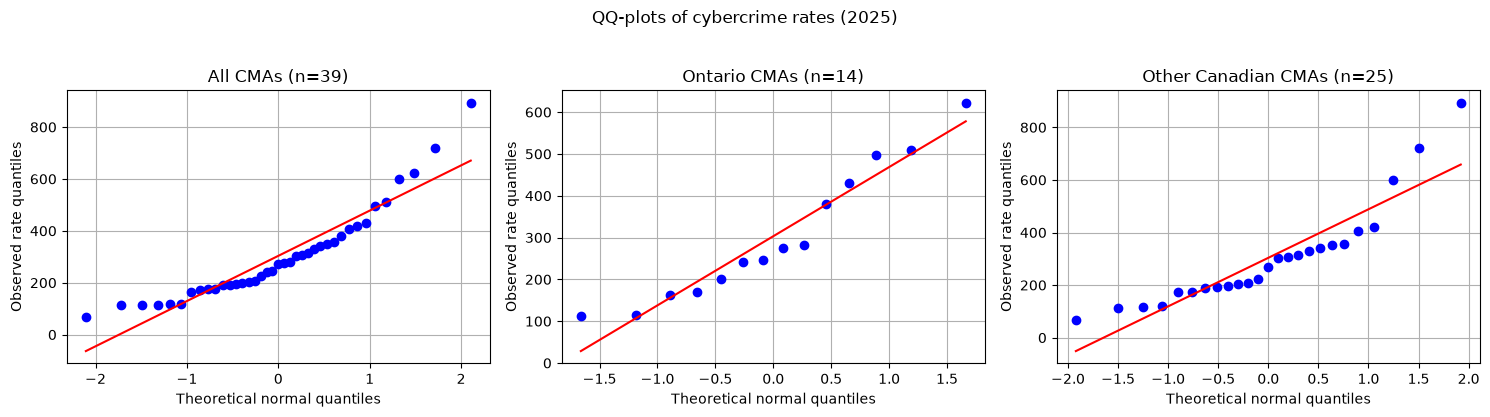

,Group,N,Shapiro_W,p_value,Reject normality at 0.05?
0,All CMAs,39,0.886,0.001,Yes
1,Ontario CMAs,14,0.922,0.236,No
2,Other Canadian CMAs,25,0.844,0.001,Yes


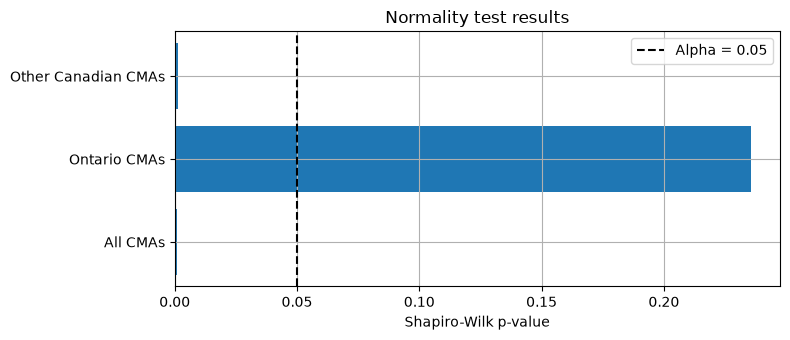

In [25]:
# Prepare the groups from the same numeric variable.
ontario = cma_df.loc[cma_df["Region_Group"] == "Ontario CMAs", "Rate_per_100k"].to_numpy()
other = cma_df.loc[cma_df["Region_Group"] == "Other Canadian CMAs", "Rate_per_100k"].to_numpy()
all_cmas = cma_df["Rate_per_100k"].to_numpy()
assert len(ontario) >= 3 and len(other) >= 3, "Shapiro-Wilk needs at least 3 values per group."

samples = {
    "All CMAs": all_cmas,
    "Ontario CMAs": ontario,
    "Other Canadian CMAs": other,
}

# QQ-plots compare observed data quantiles with theoretical normal quantiles.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, values) in zip(axes, samples.items()):
    stats.probplot(values, dist="norm", plot=ax)
    ax.set_title(f"{label} (n={len(values)})")
    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Observed rate quantiles")
plt.suptitle(f"QQ-plots of cybercrime rates ({ANALYSIS_YEAR})", y=1.03)
plt.tight_layout()
plt.show()

# Shapiro-Wilk returns the W statistic and its p-value.
normality_results = []
for label, values in samples.items():
    result = stats.shapiro(values)
    normality_results.append({
        "Group": label,
        "N": len(values),
        "Shapiro_W": result.statistic,
        "p_value": result.pvalue,
        "Reject normality at 0.05?": "Yes" if result.pvalue < ALPHA else "No",
    })
normality_df = pd.DataFrame(normality_results)
display(normality_df.round(4))

# Optional visual display of Shapiro-Wilk p-values (the test itself is numerical).
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(normality_df["Group"], normality_df["p_value"])
ax.axvline(ALPHA, color="black", linestyle="--", label="Alpha = 0.05")
ax.set(xlabel="Shapiro-Wilk p-value", title="Normality test results")
ax.legend()
plt.tight_layout()
plt.show()

### Normality assessment — **100-word** interpretation

The histogram and QQ-plots suggest that cybercrime rates are right-skewed, especially for metropolitan areas outside Ontario. Shapiro-Wilk tests support this concern: the combined sample and the other-Canada group have p-values below 0.05, so we reject normality for those samples. Ontario's p-value is above 0.05, which means we do not reject normality there; it does not prove the distribution is normal. Large differences among cities may be related to reporting and local conditions. Because some data are not normal, the F-test should be interpreted carefully, and the t-test conclusions should remain exploratory rather than definitive. These results require a contextual reading.

## 8. F-test — compare the variances of the SAME variable

An **F-test** compares the sample variances of **one variable** in **two groups**. Here, both groups contain the **cybercrime rate per 100,000 population in 2025**.

$$F = \frac{s_{\mathrm{Ontario}}^2}{s_{\mathrm{Other}}^2}$$

- H₀: The two population variances are equal.
- H₁: The population variances are different (**two-sided test**).
- We calculate an F distribution p-value using degrees of freedom `n₁−1` and `n₂−1`.

**Assumption warning:** The classical F-test is sensitive to violations of normality. Our non-Ontario group failed Shapiro–Wilk, so the F-test p-value is **not fully reliable**. We also show **Levene's test (median-centered)** as a more robust comparison. The Levene test supplements; it does not replace the required F-test.

In [26]:
# The F-statistic is the ratio of two sample variances.
n_on, n_other = len(ontario), len(other)
var_on = np.var(ontario, ddof=1)
var_other = np.var(other, ddof=1)
f_statistic = var_on / var_other
f_df1, f_df2 = n_on - 1, n_other - 1

# Two-sided p-value: area in both tails of the F distribution.
left_tail = stats.f.cdf(f_statistic, f_df1, f_df2)
right_tail = stats.f.sf(f_statistic, f_df1, f_df2)
f_pvalue = min(1.0, 2 * min(left_tail, right_tail))

# Levene's test is less sensitive to non-normal groups.
levene_stat, levene_p = stats.levene(ontario, other, center="median")

print(f"Ontario variance: {var_on:,.2f}")
print(f"Other CMA variance: {var_other:,.2f}")
print(f"F = {f_statistic:.4f}, df = ({f_df1}, {f_df2}), two-sided p = {f_pvalue:.4f}")
print(f"Levene statistic = {levene_stat:.4f}, p = {levene_p:.4f}")
print("F-test decision:", "Reject equal variance" if f_pvalue < ALPHA else "Do not reject equal variance")
print("Warning: the F-test assumes normal distributions in both groups.")

Ontario variance: 25,534.05
Other CMA variance: 37,404.21
F = 0.6827, df = (13, 24), two-sided p = 0.4789
Levene statistic = 0.0509, p = 0.8227
F-test decision: Do not reject equal variance


### F-test interpretation — workshop **50-word** summary

The F-test compares how much reported cybercrime rates vary among Ontario metropolitan areas and other Canadian metropolitan areas. Its p-value is above 0.05, so we do not find convincing evidence of different variances. However, the other-Canada rates are not normally distributed, making this classical F-test result less reliable for interpretation.

## 9. t-score (Welch independent-samples t-test) — compare mean rates

A **t-statistic** tells us how large the difference between two sample means is relative to its standard error. We use **Welch's t-test** because it accommodates different group sizes and does not require equal variances. For comparison, we calculate the t-statistic manually and verify it using SciPy.

$$t = \frac{\bar{x}_{\mathrm{Ontario}} - \bar{x}_{\mathrm{Other}}}{\sqrt{\frac{s_{\mathrm{Ontario}}^2}{n_{\mathrm{Ontario}}} + \frac{s_{\mathrm{Other}}^2}{n_{\mathrm{Other}}}}}$$

- H₀: The two groups have equal mean police-reported cybercrime rates.
- H₁: Their mean rates differ.
- A p-value below **0.05** would count as evidence against H₀ **if the test assumptions are reasonable**.

**Limitations:** CMAs have different populations, rates are analyzed with **equal weight per CMA**, and one comparison group is right-skewed. These are **exploratory statistics**, not a causal conclusion and not a model of individual victimization.

In [27]:
# Calculate the difference between group means and its standard error.
mean_on, mean_other = np.mean(ontario), np.mean(other)
mean_difference = mean_on - mean_other
standard_error = np.sqrt(var_on / n_on + var_other / n_other)
t_statistic = mean_difference / standard_error

# Welch-Satterthwaite approximation for degrees of freedom.
welch_df = (var_on / n_on + var_other / n_other) ** 2 / (
    (var_on / n_on) ** 2 / (n_on - 1)
    + (var_other / n_other) ** 2 / (n_other - 1)
)

# A two-sided p-value and 95% confidence interval.
t_pvalue = 2 * stats.t.sf(abs(t_statistic), df=welch_df)
t_critical = stats.t.ppf(1 - ALPHA / 2, df=welch_df)
ci_lower = mean_difference - t_critical * standard_error
ci_upper = mean_difference + t_critical * standard_error

# Check our manual calculation against scipy.stats.
scipy_t = stats.ttest_ind(ontario, other, equal_var=False)
assert np.isclose(t_statistic, scipy_t.statistic)
assert np.isclose(t_pvalue, scipy_t.pvalue)

print(f"Ontario mean: {mean_on:.2f} per 100,000 (n={n_on})")
print(f"Other CMAs mean: {mean_other:.2f} per 100,000 (n={n_other})")
print(f"Mean difference (Ontario - other): {mean_difference:.2f}")
print(f"Welch t = {t_statistic:.4f}, degrees of freedom ≈ {welch_df:.2f}")
print(f"Two-sided p-value = {t_pvalue:.4f}")
print(f"95% CI for difference = [{ci_lower:.2f}, {ci_upper:.2f}]")
print("Decision:", "Reject equal means" if t_pvalue < ALPHA else "Do not reject equal means")

Ontario mean: 303.26 per 100,000 (n=14)
Other CMAs mean: 303.79 per 100,000 (n=25)
Mean difference (Ontario - other): -0.53
Welch t = -0.0092, degrees of freedom ≈ 31.57
Two-sided p-value = 0.9928
95% CI for difference = [-117.96, 116.90]
Decision: Do not reject equal means


### t-score interpretation — workshop **50-word** summary

The Welch t-test compares the average police-reported cybercrime rate in Ontario metropolitan areas with the average elsewhere in Canada. The group means are almost identical, and the p-value is far above 0.05. We cannot conclude that the average rates differ. This result is exploratory because distributions are skewed overall here.

**Additional note for the slide-35 in-class activity:**

Welch's method is preferable to a pooled t-test here because our group sizes differ, and we do not need to assume equal variances. The confidence interval includes zero, which agrees with the p-value. Because our sample consists of cities rather than randomly selected people, we avoid making population-wide causal claims.

## 10. In-class Activity #1 (Unit 3, slide 35) — applied to cybercrime

The original slide asks students to investigate food prices for decision-makers. We adapt the same process to **Canadian police-reported cybercrime**. A suitable **target audience** is a public-sector analyst, a municipal policy team, or a community safety organization.

| Slide-35 request | What we did |
|---|---|
| Find the distribution | 2025 CMA cybercrime **rates** visualized with histograms. |
| Apply and interpret Z-score | Mean/standard deviation and unusually high or low CMA values. |
| Apply and interpret t-score | Welch comparison: Ontario CMA rates versus other Canadian CMAs. |
| Apply Shapiro–Wilk | Normality tests on all CMAs and both groups. |
| Assess p-values | Shapiro–Wilk, F-test, and Welch t-test results interpreted with alpha = 0.05. |
| Which visualization? | **Histograms** for explaining the data to a general audience; **QQ-plots** for checking normality. |

**Normalizing vs. being normally distributed:** Converting a value to a Z-score standardizes its **scale**; it does **not** make a skewed distribution become normal. We need to check normality separately.

**Team collaboration to complete before submission:** record the GitHub commit/PR contributions and add your MS Teams / shared whiteboard link **only if the team actually created one**. Do not claim that a meeting happened unless it did.

### Slide-35 reflection on p-values — **100 words**

Our Shapiro-Wilk tests indicate that the combined sample of metropolitan areas and the group outside Ontario are not normally distributed at the five-percent significance level. Ontario alone does not show strong evidence against normality. The F-test does not detect a clear difference between the two sample variances, but that test relies on normality and therefore needs caution. The Welch t-test also finds no evidence of different mean rates between the groups. A nonsignificant p-value is not proof that two populations are identical. These results describe police reports, not the total number of cybercrimes that occurred without additional contextual information available.

### References
- Statistics Canada. *Table 35-10-0002-01: Police-reported cybercrime, number of incidents and rate per 100,000 population*. https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=3510000201
- Statistics Canada. *Uniform Crime Reporting Survey — metadata and footnotes*, provided in `35100002_MetaData.csv`.
- Course material: *PROG8431, Unit 1 slides 11–24 and Unit 3 slides 1–35*.
- Course assignment: *Problem Analysis Workshop A*, due October 8, 2026.
